In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import make_scorer, matthews_corrcoef, f1_score, balanced_accuracy_score, precision_score, recall_score, precision_recall_curve, average_precision_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
#1. Load data
df = pd.read_csv('ppi.csv')

In [ ]:
# 2. Splitting 
unique_proteins = df['uniprot_id'].unique()
train_val_ids, test_ids = train_test_split(unique_proteins, test_size=0.20, random_state=22)
train_ids, val_ids = train_test_split(train_val_ids, test_size=0.25, random_state=23)
train_data = df[df['uniprot_id'].isin(train_ids)]

In [ ]:
# 3. MODELS  WITHOUT LENGTH AND NORMALIEZED LENGTH
metadata = ['Unnamed: 0', 'domain', 'aa_ProtPosition', 'uniprot_id', 'Rlength', 'sequence', 'normalized_length', 'p_interface']

# Base only: no windows
base_features = [
    'normalized_abs_surf_acc', 'normalized_hydropathy_index', 'rel_surf_acc',
    'prob_sheet', 'prob_helix', 'prob_coil'
] + [c for c in df.columns if c.startswith('pssm_') and '_wm_' not in c]

feature_sets = {
    "Model 1: Base Only": base_features,
    "Model 2: Window 3 Only": [c for c in df.columns if c.startswith('3_wm_')],
    "Model 3: Window 5 Only": [c for c in df.columns if c.startswith('5_wm_')],
    "Model 4: Window 7 Only": [c for c in df.columns if c.startswith('7_wm_')],
    "Model 5: Window 9 Only": [c for c in df.columns if c.startswith('9_wm_')]
}

In [ ]:
#4. Imbalance Configurations 
ros = RandomOverSampler(random_state=44)
rus = RandomUnderSampler(random_state=33)
y_train = train_data['p_interface']
xgb_ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

configs = [
    ("RF (Undersampled)", Pipeline([
        ('resampler', rus), 
        ('model', RandomForestClassifier(
            n_estimators=400,           
            max_depth=None,           
            max_features='sqrt',        
            min_samples_split=2,        
            random_state=66, 
            n_jobs=-1
        ))
    ])),
    
    ("XGBoost (Class Weight)", XGBClassifier(
        scale_pos_weight=xgb_ratio, 
        learning_rate=0.01,            
        n_estimators=500,               
        max_depth=10,                  
        subsample=0.8,                  
        colsample_bytree=0.8,           
        eval_metric='logloss', 
        random_state=100
    ))
]

In [ ]:
#5. Metrics & CV
scoring = {
    'MCC': make_scorer(matthews_corrcoef),
    'F1': make_scorer(f1_score, zero_division=0),
    'ROC-AUC': 'roc_auc',
    'Bal.Acc': make_scorer(balanced_accuracy_score),
    'Precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'Recall': make_scorer(recall_score, zero_division=0)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
output_dir = 'model_outputs'
os.makedirs(output_dir, exist_ok=True)

final_results = []
saved_files_registry = {} 

for model_name, features in feature_sets.items():
    print(f"Testing {model_name}...")
    X_train_sub = train_data[features]
    y_train = train_data['p_interface']
    
    for config_name, clf in configs:
        y_probas = cross_val_predict(clf, X_train_sub, y_train, cv=cv, method='predict_proba', n_jobs=-1)
        probs = y_probas[:, 1]
        
        safe_model = model_name.replace(" ", "_").replace(":", "").replace("+", "plus")
        safe_config = config_name.replace(" ", "_").replace("(", "").replace(")", "")
        filename = f"{safe_model}_{safe_config}.csv"
        file_path = os.path.join(output_dir, filename)
       
        pd.DataFrame({'y_true': y_train, 'y_prob': probs}).to_csv(file_path, index=False)
        

        if config_name not in saved_files_registry:
            saved_files_registry[config_name] = []
        saved_files_registry[config_name].append((model_name, file_path))
        
        scores = cross_validate(clf, X_train_sub, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        final_results.append({
            'Model': model_name, 'Config': config_name,
            'MCC': np.mean(scores['test_MCC']).round(3),
            'F1': np.mean(scores['test_F1']).round(3),
            'AUC': np.mean(scores['test_ROC-AUC']).round(3),
            'Bal.Acc': np.mean(scores['test_Bal.Acc']).round(3),    
            'Precision': np.mean(scores['test_Precision']).round(3), 
            'Recall': np.mean(scores['test_Recall']).round(3)

        })

print("\n--- DONE: Files saved to model_outputs/ ---")

Testing Model 1: Base Only...
Testing Model 2: Window 3 Only...
Testing Model 3: Window 5 Only...
Testing Model 4: Window 7 Only...
Testing Model 5: Window 9 Only...

--- DONE: Files saved to model_outputs/ ---


In [ ]:
# Summary table
results_df = pd.DataFrame(final_results)
print("\n--- FINAL CROSS-VALIDATION RESULTS ---")
print(results_df.to_string(index=False))


--- FINAL CROSS-VALIDATION RESULTS ---
                 Model                 Config   MCC    F1   AUC  Bal.Acc  Precision  Recall
    Model 1: Base Only      RF (Undersampled) 0.119 0.254 0.622    0.592      0.160   0.611
    Model 1: Base Only XGBoost (Class Weight) 0.100 0.221 0.621    0.557      0.191   0.264
Model 2: Window 3 Only      RF (Undersampled) 0.154 0.273 0.674    0.619      0.172   0.671
Model 2: Window 3 Only XGBoost (Class Weight) 0.141 0.247 0.680    0.574      0.235   0.260
Model 3: Window 5 Only      RF (Undersampled) 0.208 0.304 0.729    0.661      0.192   0.733
Model 3: Window 5 Only XGBoost (Class Weight) 0.202 0.310 0.728    0.619      0.260   0.383
Model 4: Window 7 Only      RF (Undersampled) 0.251 0.330 0.769    0.693      0.209   0.780
Model 4: Window 7 Only XGBoost (Class Weight) 0.245 0.347 0.758    0.655      0.270   0.487
Model 5: Window 9 Only      RF (Undersampled) 0.280 0.349 0.797    0.715      0.222   0.806
Model 5: Window 9 Only XGBoost (Class We

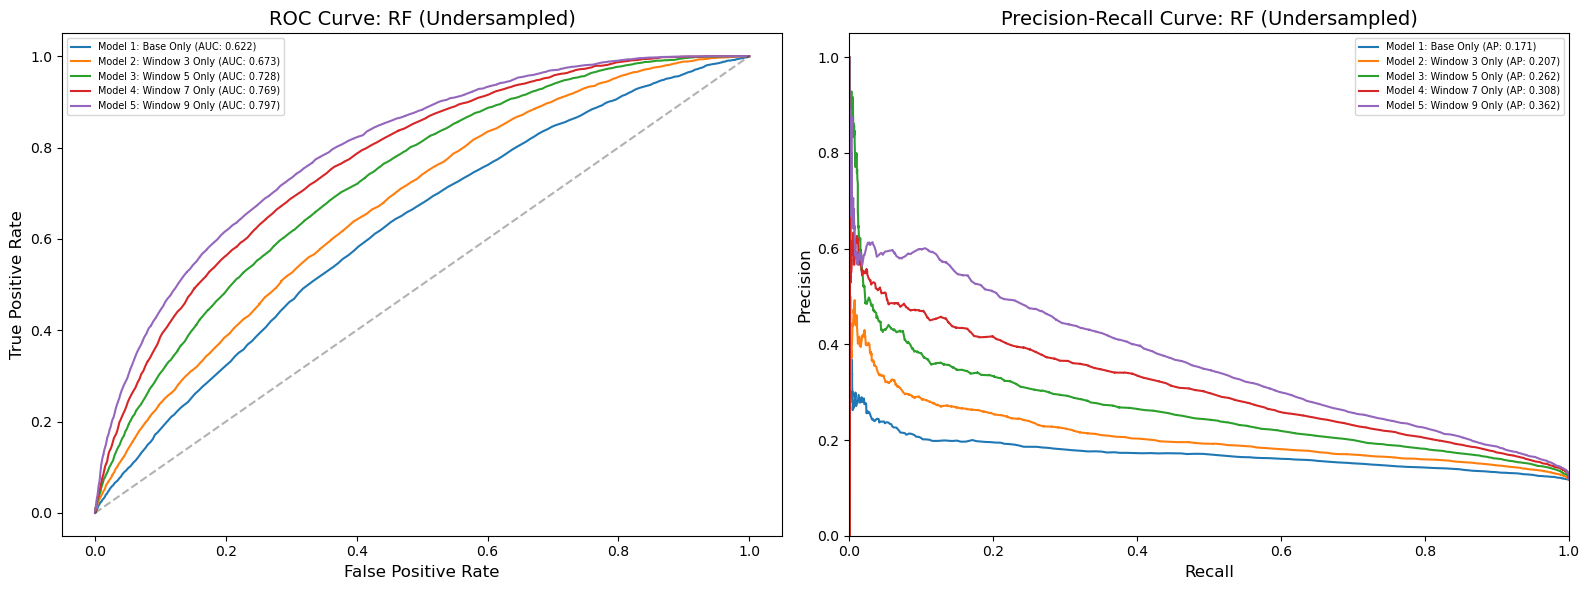

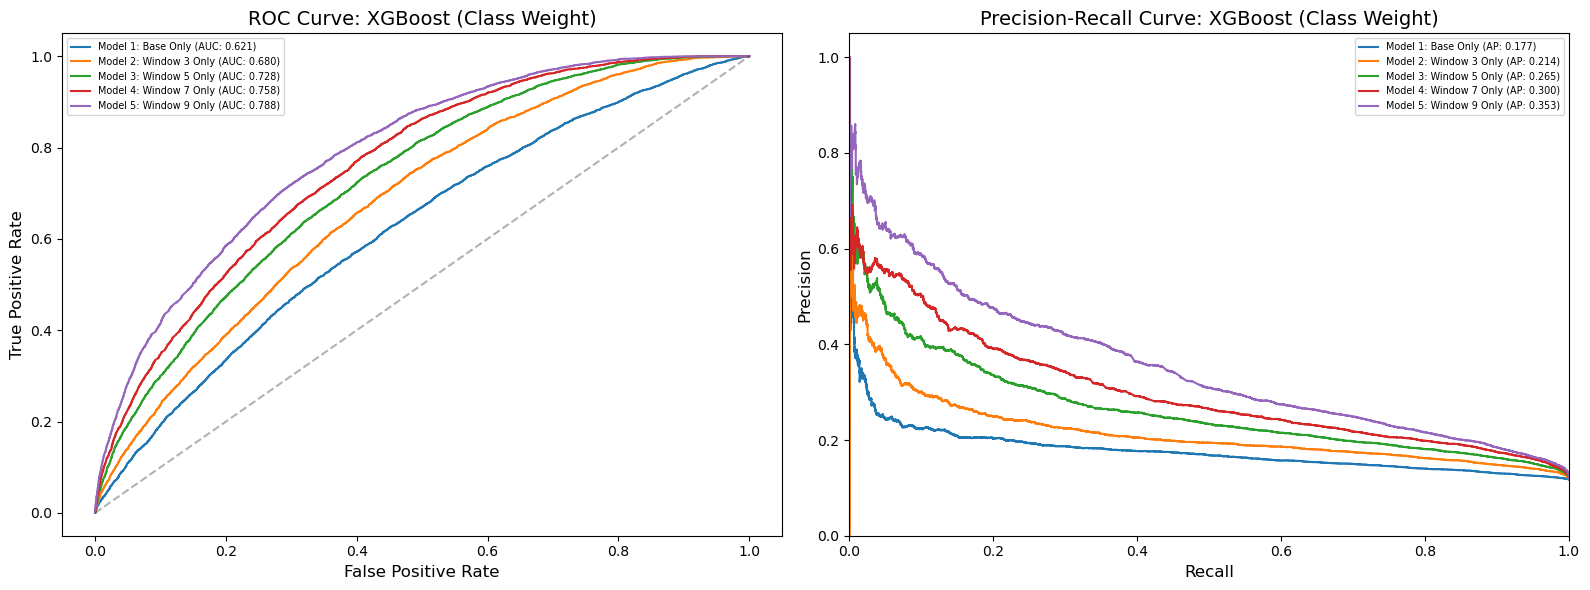

In [ ]:
# 6. Plotting ROC and PR Curves
for config_name, file_info_list in saved_files_registry.items():
    if config_name not in ["RF (Undersampled)", "XGBoost (Class Weight)"]:
        continue
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for model_label, path in file_info_list:
        if not os.path.exists(path):
            continue
            
        data = pd.read_csv(path)
        y_true, y_prob = data['y_true'], data['y_prob']

        # 1. ROC Calculation
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ax1.plot(fpr, tpr, label=f'{model_label} (AUC: {auc(fpr, tpr):.3f})')
        
        # 2. PR Calculation
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ax2.plot(recall, precision, label=f'{model_label} (AP: {average_precision_score(y_true, y_prob):.3f})')

    # ROC
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax1.set_title(f'ROC Curve: {config_name}', fontsize=14)
    ax1.set_xlabel('False Positive Rate', fontsize=12) 
    ax1.set_ylabel('True Positive Rate', fontsize=12)  
    ax1.legend(fontsize='x-small')
    
    # PR
    ax2.set_title(f'Precision-Recall Curve: {config_name}', fontsize=14)
    ax2.set_xlabel('Recall', fontsize=12)             
    ax2.set_ylabel('Precision', fontsize=12)          
    ax2.set_xlim([0, 1.0])
    ax2.set_ylim([0, 1.05])
    ax2.legend(fontsize='x-small')
    
    plt.tight_layout()
    plt.show()

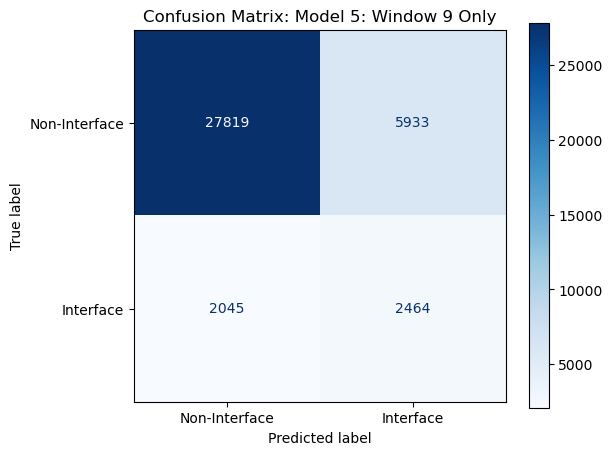

Calculating Feature Importance for Model 5: Window 9 Only...


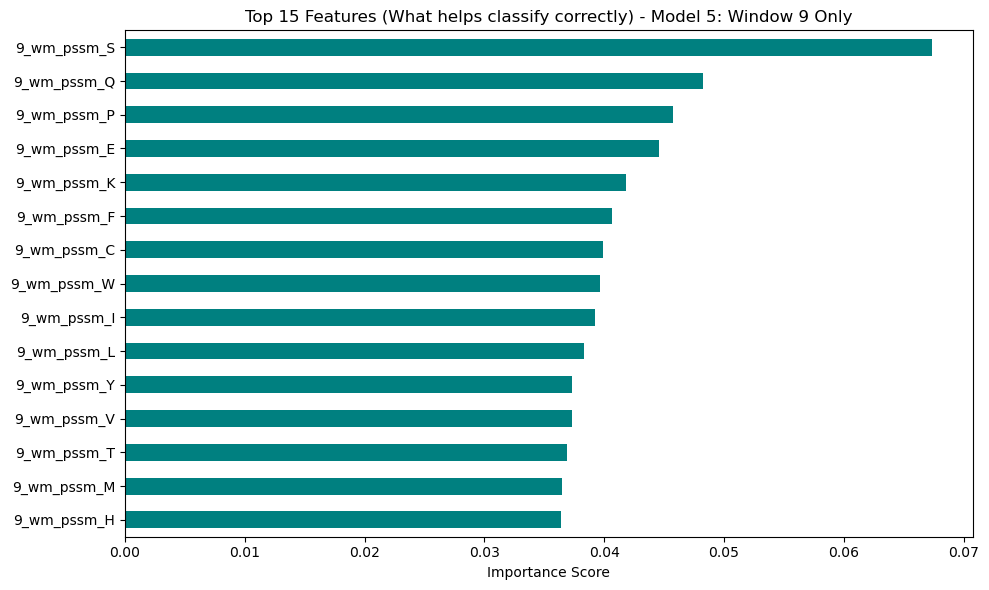


--- Feature Analysis Complete ---
Top 5 most influential features:
9_wm_pssm_S    0.067379
9_wm_pssm_Q    0.048260
9_wm_pssm_P    0.045710
9_wm_pssm_E    0.044554
9_wm_pssm_K    0.041803
dtype: float32


In [ ]:
# 7. CONFUSION MATRIX OF THE XGBOOST: Model 5: Window 9 Only
target_model = "Model 5: Window 9 Only"
target_config = "XGBoost (Class Weight)" 

# 1. Confusion Matrix
file_path = f"model_outputs/{target_model.replace(' ', '_').replace(':', '').replace('+', 'plus')}_{target_config.replace(' ', '_').replace('(', '').replace(')', '')}.csv"

if os.path.exists(file_path):
    data = pd.read_csv(file_path)
    # Convert probabilities to binary predictions (Threshold = 0.5)
    y_pred = (data['y_prob'] >= 0.5).astype(int)
    cm = confusion_matrix(data['y_true'], y_pred)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Interface', 'Interface'])
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix: {target_model}")
    plt.show()

# 2. Feature Importance 
print(f"Calculating Feature Importance for {target_model}...")
X_analysis = train_data[feature_sets[target_model]]
y_analysis = train_data['p_interface']

best_xgb = configs[1][1] 
best_xgb.fit(X_analysis, y_analysis)

# Extract and Sort Importance
importances = best_xgb.feature_importances_
feature_names = X_analysis.columns
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
feat_importances.head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title(f"Top 15 Features (What helps classify correctly) - {target_model}")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\n--- Feature Analysis Complete ---")
print("Top 5 most influential features:")
print(feat_importances.head(5))

--- Deep Error Analysis: Model 5: Window 9 Only (XGBoost) ---


/var/folders/mc/lcy429t16f3_pd0d1jks5bv80000gn/T/ipykernel_89990/690529123.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Value', data=plot_df, ax=axes[i], palette='Set2')
/var/folders/mc/lcy429t16f3_pd0d1jks5bv80000gn/T/ipykernel_89990/690529123.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Value', data=plot_df, ax=axes[i], palette='Set2')
/var/folders/mc/lcy429t16f3_pd0d1jks5bv80000gn/T/ipykernel_89990/690529123.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Value', data

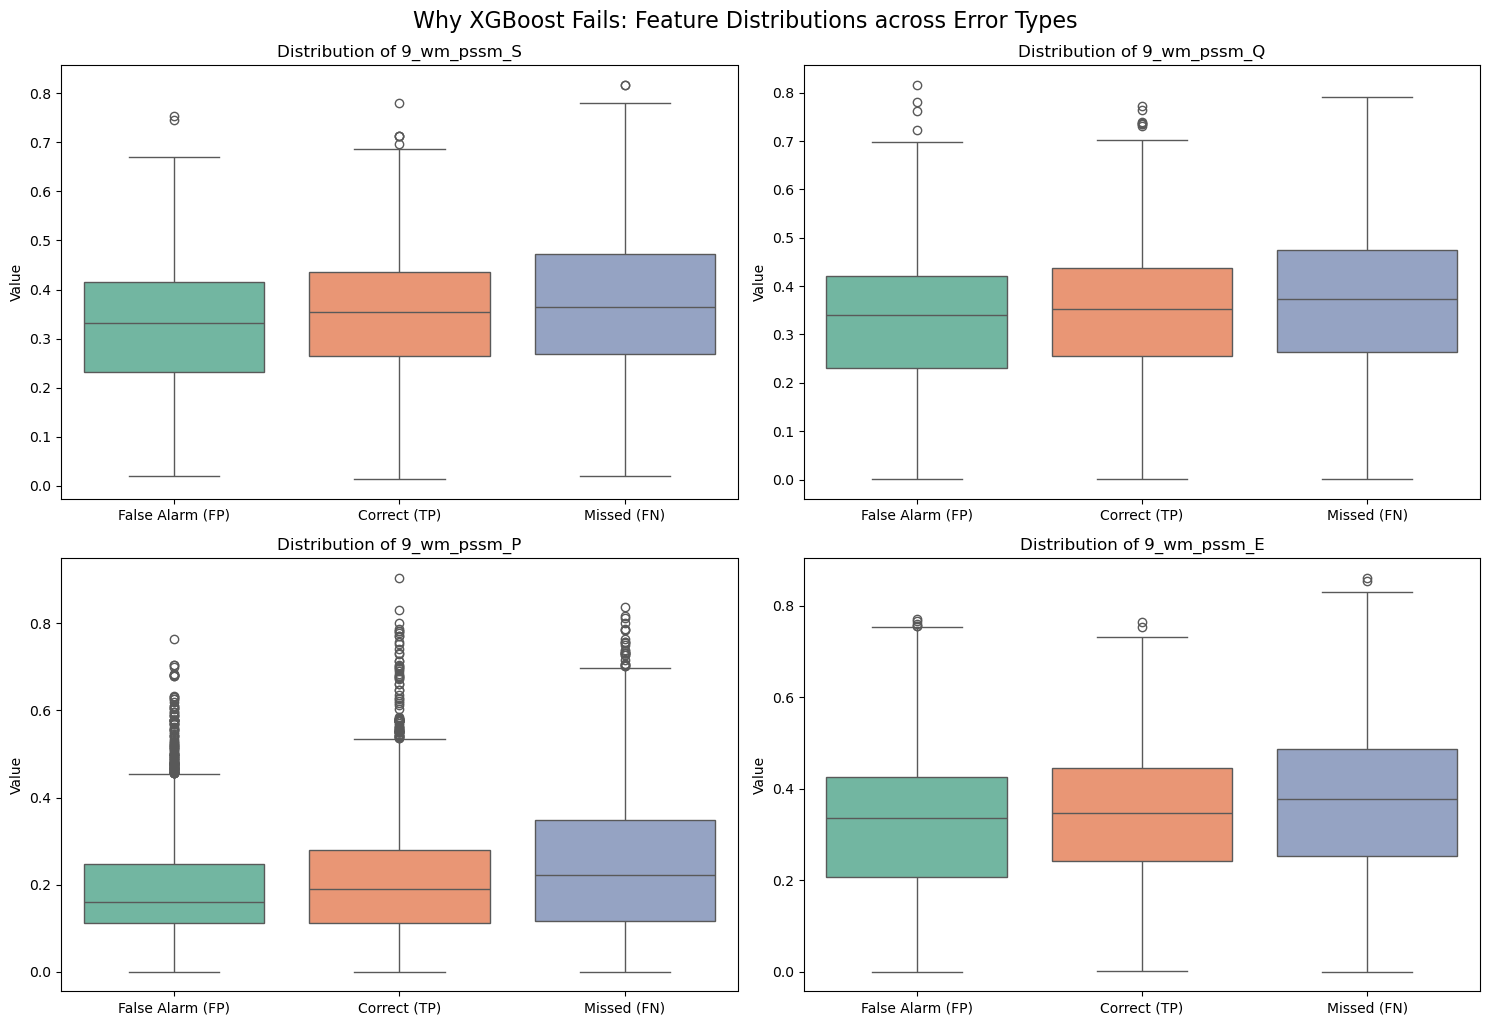


--- STATISTICAL COMPARISON OF ERRORS ---
    Feature  TP_Mean (Correct)  FN_Mean (Missed)  FP_Mean (False Alarm)
9_wm_pssm_S           0.347060          0.369461               0.316114
9_wm_pssm_Q           0.342613          0.370190               0.322432
9_wm_pssm_P           0.210396          0.245629               0.185638
9_wm_pssm_E           0.341379          0.372022               0.322541


In [ ]:
# 8. Statistical Error Analysis: Model 5 (XGBoost)

# 1. Data
target_model_name = "Model 5: Window 9 Only"
X_analysis = train_data[feature_sets[target_model_name]]
y_analysis = train_data['p_interface']
best_xgb = configs[1][1] # XGBoost (Class Weight) config

# 2. Out of fold predictions 
y_probs = cross_val_predict(best_xgb, X_analysis, y_analysis, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
y_pred = (y_probs >= 0.5).astype(int)

# 3. Error groups
tp_idx = (y_analysis == 1) & (y_pred == 1) # Correct Interface
tn_idx = (y_analysis == 0) & (y_pred == 0) # Correct Non-Interface
fp_idx = (y_analysis == 0) & (y_pred == 1) # False Alarm
fn_idx = (y_analysis == 1) & (y_pred == 0) # Missed

# 4.Top Features 
best_xgb.fit(X_analysis, y_analysis)
feat_importances = pd.Series(best_xgb.feature_importances_, index=X_analysis.columns).sort_values(ascending=False)
top_features = feat_importances.head(5).index.tolist()

# 5. Table with the mean values of features across different prediction outcomes
error_stats = pd.DataFrame({
    'Feature': top_features,
    'TP_Mean (Correct)': [X_analysis.loc[tp_idx, f].mean() for f in top_features],
    'FN_Mean (Missed)': [X_analysis.loc[fn_idx, f].mean() for f in top_features],
    'FP_Mean (False Alarm)': [X_analysis.loc[fp_idx, f].mean() for f in top_features],
    'Diff (TP vs FN)': [X_analysis.loc[tp_idx, f].mean() - X_analysis.loc[fn_idx, f].mean() for f in top_features]
})

print(f"--- STATISTICAL COMPARISON OF ERRORS: {target_model_name} ---")
print(error_stats.to_string(index=False))